In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
train_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
test_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Train Images:", len(train_dataset))
print("Test Images:", len(test_dataset))

Device: cuda
Train Images: 14034
Test Images: 3000


In [3]:
import gc

gc.collect()
torch.cuda.empty_cache()

print("GPU Cleared")

GPU Cleared


In [4]:
MODEL_NAME = "vit_small_patch14_dinov2"

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=6,
    dynamic_img_size=True
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

print("DINOv2 Loaded Successfully")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

DINOv2 Loaded Successfully


In [5]:
epochs = 20

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}"
    )

Epoch [1/20] Loss: 1.2458
Epoch [2/20] Loss: 0.9713
Epoch [3/20] Loss: 0.8696
Epoch [4/20] Loss: 0.7993
Epoch [5/20] Loss: 0.7496
Epoch [6/20] Loss: 0.7096
Epoch [7/20] Loss: 0.6659
Epoch [8/20] Loss: 0.6285
Epoch [9/20] Loss: 0.5869
Epoch [10/20] Loss: 0.5537
Epoch [11/20] Loss: 0.5222
Epoch [12/20] Loss: 0.4962
Epoch [13/20] Loss: 0.4643
Epoch [14/20] Loss: 0.4394
Epoch [15/20] Loss: 0.4108
Epoch [16/20] Loss: 0.3925
Epoch [17/20] Loss: 0.3681
Epoch [18/20] Loss: 0.3366
Epoch [19/20] Loss: 0.3151
Epoch [20/20] Loss: 0.3028


In [7]:
# EVALUATION

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\nRESULTS")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


RESULTS
Accuracy : 0.797
Precision: 0.8009102279423409
Recall   : 0.797
F1 Score : 0.7976711823008086


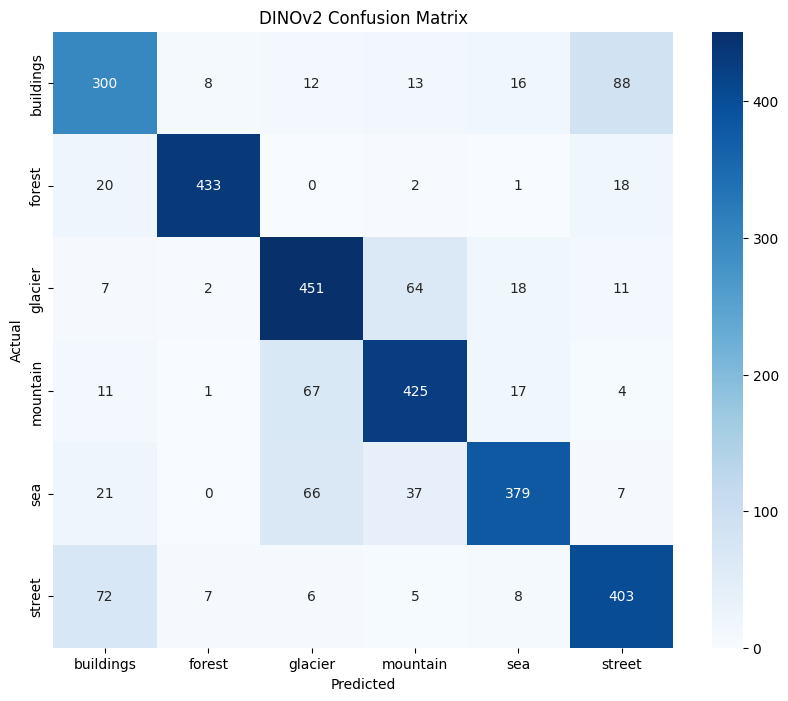

In [8]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("DINOv2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

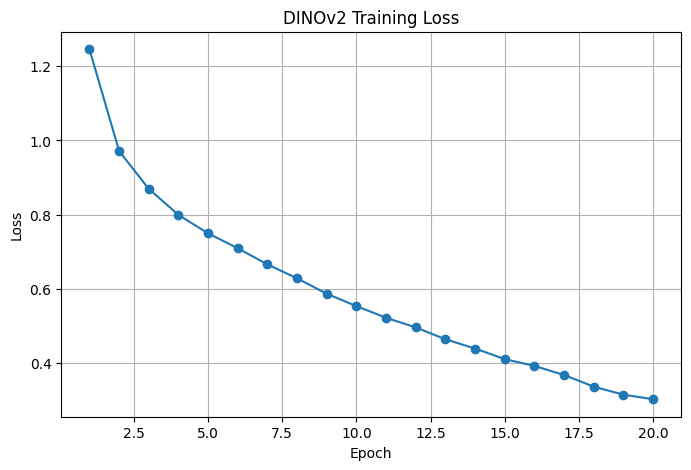

In [9]:
# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    range(1,21),
    train_losses,
    marker='o'
)

plt.title("DINOv2 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()